**Ex 1**

Linear deformation modulus at lon=0.0, lat=30.0: 0.9996
Linear deformation modulus at lon=0.5, lat=30.0: 0.9996285464599518
Linear deformation modulus at lon=1.0, lat=30.0: 0.9997141858398072
Linear deformation modulus at lon=1.5, lat=30.0: 0.999856918139566
Linear deformation modulus at lon=2.0, lat=30.0: 1.0000567433592282
Linear deformation modulus at lon=2.5, lat=30.0: 1.0003136614987942
Linear deformation modulus at lon=3.0, lat=30.0: 1.0006276725582635
Linear deformation modulus at lon=0.0, lat=37.0: 0.9996
Linear deformation modulus at lon=0.5, lat=37.0: 0.9996242766204607
Linear deformation modulus at lon=1.0, lat=37.0: 0.9996971064818421
Linear deformation modulus at lon=1.5, lat=37.0: 0.9998184895841449
Linear deformation modulus at lon=2.0, lat=37.0: 0.9999884259273686
Linear deformation modulus at lon=2.5, lat=37.0: 1.0002069155115134
Linear deformation modulus at lon=3.0, lat=37.0: 1.0004739583365794
Linear deformation modulus at lon=0.0, lat=45.0: 0.9996
Linear deformatio

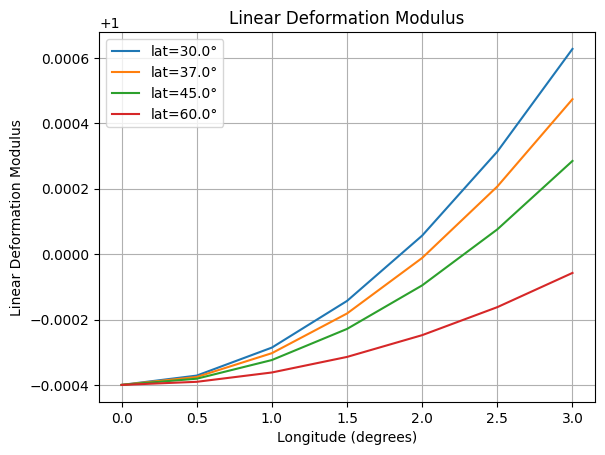

In [3]:
#** Ex1 **

import math
import numpy as np
import matplotlib.pyplot as plt

# function to evaluate the moduls of linear deformation
def linear_deformation_modulus(lon, lat):
    return k_0 * (1 + (lon**2)/2 * math.cos(lat)**2)

lons = np.arange(0.0, 3.5, 0.5)
lats = [30.0, 37.0, 45.0, 60.0]
k_0 = 0.9996  # scale factor

for lat in lats:
    modulus = []
    for lon in lons:
        # convert in radians
        lon_rad = math.radians(lon)
        lat_rad = math.radians(lat)
        # Calculate the linear deformation modulus
        modulus.append(linear_deformation_modulus(lon_rad, lat_rad))
        print(f"Linear deformation modulus at lon={lon}, lat={lat}: {modulus[-1]}")

    # show a plot of the linear deformation modulus
    plt.plot(lons, modulus, label=f'lat={lat}°')
plt.title('Linear Deformation Modulus')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Linear Deformation Modulus')
plt.legend()
plt.grid()
plt.show()

**Ex 2**

In [18]:
import numpy as np
import math

# WGS84 parameters
a = 6378137.0  # semi-major axis
c = 6356752.314245179
e2 = 0.006694379990141316
e_prime_sq = 0.0067394967422764337
Rp = a**2 / c  # polar radius

k_0 = 0.9996  # scale factor

# Coefficients for meridional arc
A_1 = 1 - e2 / 4 - 3 * e2**2 / 64 - 5 * e2**3 / 256
A_2 = 3/8 * (e2 + e2**2 / 4 + 15 * e2**3 / 128)
A_4 = 15/256 * (e2**2 + 3 * e2**3 / 4)
A_6 = 35 * e2**3 / 3072

def dms_to_decimal(d, m, s):
    return d + m / 60 + s / 3600

def meridional_arc(phi):
    return a * (A_1 * phi - A_2 * math.sin(2 * phi) + A_4 * math.sin(4 * phi) - A_6 * math.sin(6 * phi))

def lat_lon_to_utm(lat_deg, lon_deg, zone):
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    
    # Central meridian of the zone in radians
    lon0 = math.radians((zone - 1) * 6 - 180 + 3)

    lon_ = lon - lon0  # difference from central meridian

    v1 = np.sqrt(1 + e_prime_sq * np.cos(lat)**2)
    E = np.arctan2(np.tan(lat), np.cos(v1 * lon_))
    v = np.sqrt(1 + e_prime_sq * np.cos(E)**2)
    
    x = Rp * np.arcsinh(np.cos(E) * np.tan(lon_)) / v
    y = meridional_arc(E)

    east = x * k_0 + 500000  # Easting, add false easting
    north = y * k_0  # Northing
    
    # If southern hemisphere, add false northing
    if lat_deg < 0:
        y += 10000000
    
    return east, north

# Input points
lat1 = dms_to_decimal(45, 3, 45.717)
lon1 = dms_to_decimal(7, 47, 26.292)

lat2 = dms_to_decimal(38, 32, 34.649)
lon2 = dms_to_decimal(16, 50, 6.493)

x1, y1 = lat_lon_to_utm(lat1, lon1, 32)
x2, y2 = lat_lon_to_utm(lat2, lon2, 33)

print(f"P1 UTM Zone 32: Easting = {x1:.3f}, Northing = {y1:.3f}")
print(f"P2 UTM Zone 33: Easting = {x2:.3f}, Northing = {y2:.3f}")

P1 UTM Zone 32: Easting = 404787.699, Northing = 4990626.882
P2 UTM Zone 33: Easting = 659931.060, Northing = 4267656.350


**Ex 3**

In [24]:
# use the hirvonen equation to convert the coordinates from cartographic to geographic coordinates

import math

# WGS84 parameters
a = 6378137.0  # semi-major axis
f = 1 / 298.257223563
b = a * (1 - f)  # semi-minor axis
e2 = 2 * f - f**2  # first eccentricity squared
e_prime_sq = e2 / (1 - e2)  # second eccentricity squared
Rp = a**2 / b  # polar radius

k_0 = 0.9996  # scale factor

A_1 = 1 - e2 / 4 - 3 * e2**2 / 64 - 5 * e2**3 / 256
A_2 = 3/8 * (e2 + e2**2 / 4 + 15 * e2**3 / 128)
A_4 = 15/256 * (e2**2 + 3 * e2**3 / 4)
A_6 = 35 * e2**3 / 3072

# WGS84 and UTM 32
cartographic_cordinates = [470139.66, 5031468.37]

def utm_to_lat_lon(east, north, zone):
    # Central meridian of the zone in radians
    lon0 = math.radians((zone - 1) * 6 - 180 + 3)
    
    # Adjust for false easting
    east -= 500000
    
    # If southern hemisphere, adjust northing
    if north < 0:
        north -= 10000000
    
    # Calculate meridional arc
    M = north / k_0
    
    # Calculate latitude
    mu = M / (a * A_1)
    
    phi1 = mu + (3 * A_2 * math.sin(2 * mu) / 2) + (5 * A_4 * math.sin(4 * mu) / 4) + (35 * A_6 * math.sin(6 * mu) / 6)
    
    # Calculate latitude and longitude
    N1 = a / np.sqrt(1 - e2 * np.sin(phi1)**2)
    T1 = np.tan(phi1)**2
    C1 = e_prime_sq * np.cos(phi1)**2
    R1 = a * (1 - e2) / (1 - e2 * np.sin(phi1)**2)**(3/2)
    
    D = east / (N1 * k_0)
    
    lat = phi1 - (N1 * np.tan(phi1) / R1) * (D**2 / 2 - (5 + 3*T1 + 10*C1 - 4*C1**2 - 9*e_prime_sq) * D**4 / 24)
    
    lat_deg = math.degrees(lat)
    
    lon = lon0 + (D - (1 + 2*T1 + C1) * D**3 / 6 + (5 - T1 + 9*C1 + 4*C1**2) * D**5 / 120) / np.cos(phi1)
    
    lon_deg = math.degrees(lon)
    
    return lat_deg, lon_deg

lat_lon = utm_to_lat_lon(cartographic_cordinates[0], cartographic_cordinates[1], 32)
# convert to latitude and longitude in DMS
def decimal_to_dms(deg):
    d = int(deg)
    m = int((abs(deg) - abs(d)) * 60)
    s = (abs(deg) - abs(d)) * 60
    s = (s - m) * 60
    return f"{d}°{m}'{s:.2f}\""

lat_dms = decimal_to_dms(lat_lon[0])
lon_dms = decimal_to_dms(lat_lon[1])
print(f"Latitude = {lat_dms}, Longitude = {lon_dms}")

Latitude = 45°30'28.41", Longitude = 8°37'3.87"
